In [ ]:
#Python DA Assignment 2 - Data Visualization

In [ ]:
#1) Loading the Taxis Dataset

In [13]:
import pandas as pd

In [15]:
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [4]:
## Load the 'taxis' dataset

df = sns.load_dataset("taxis")

In [ ]:
#2) Handling Missing Values

In [8]:
# 1. Total missing values per column
missing_values = df.isnull().sum()

# 2. Filter and display only columns with missing values (> 0)
columns_with_missing = missing_values[missing_values > 0]

print("Missing values per column:")
print(columns_with_missing)


Missing values per column:
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [9]:
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [10]:
# 1. Impute Categorical Columns using Mode
categorical_cols = ["payment", "pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]

for col in categorical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# 2. Impute Numerical Columns using Median (if any numerical columns have missing values)
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Verify that all missing values are handled
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [11]:
# 2. Define critical columns where missing values should not be artificially filled
critical_cols = ["pickup_borough", "dropoff_borough", "pickup_zone", "dropoff_zone"]

# 3. Drop rows where critical location data is missing
df_clean = df.dropna(subset=critical_cols).copy()

# 4. Handle non-critical/general categorical missing values (e.g., 'payment') via mode imputation
if "payment" in df_clean.columns:
    payment_mode = df_clean["payment"].mode()[0]
    df_clean["payment"] = df_clean["payment"].fillna(payment_mode)

# Check results
print(f"Original row count: {len(df)}")
print(f"Cleaned row count:  {len(df_clean)}")
print("\nRemaining missing values per column:")
print(df_clean.isnull().sum())

Original row count: 6433
Cleaned row count:  6433

Remaining missing values per column:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [ ]:
#3) Visualizations using Matplotlib/Pandas Plot:

In [ ]:
#Line Chart

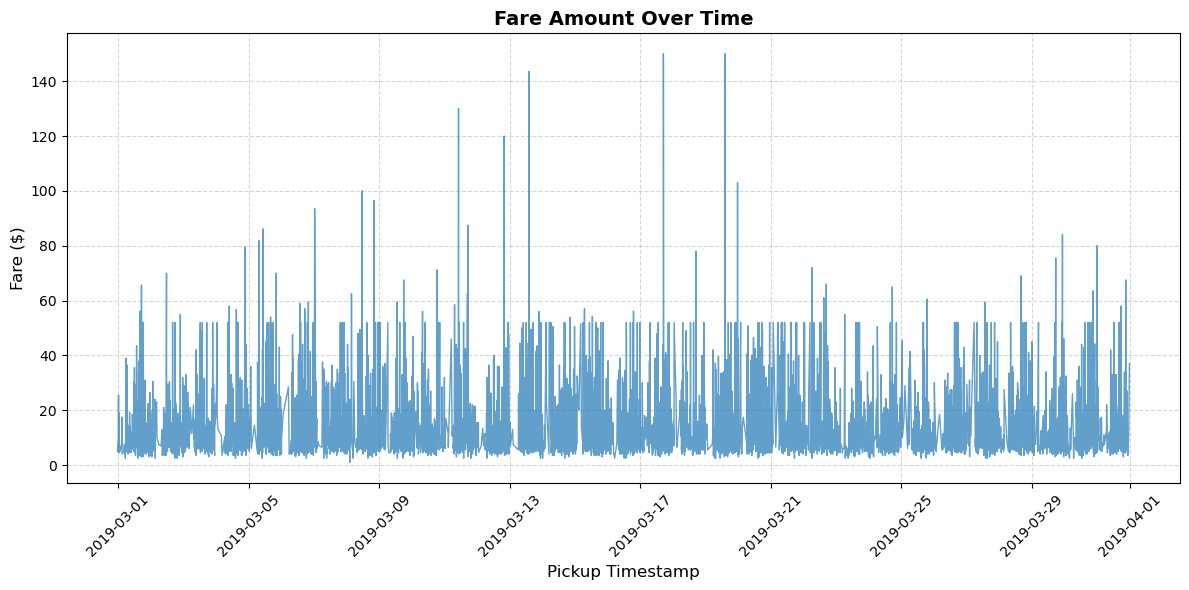

In [16]:
# .Convert 'pickup' column to datetime format
df['pickup'] = pd.to_datetime(df['pickup'])

# . Sort by timestamp for proper chronological plotting
df = df.sort_values('pickup')

# . Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'], color='tab:blue', linewidth=1, alpha=0.7)

# . Formatting and labels
plt.title('Fare Amount Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Timestamp', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Bar Chart

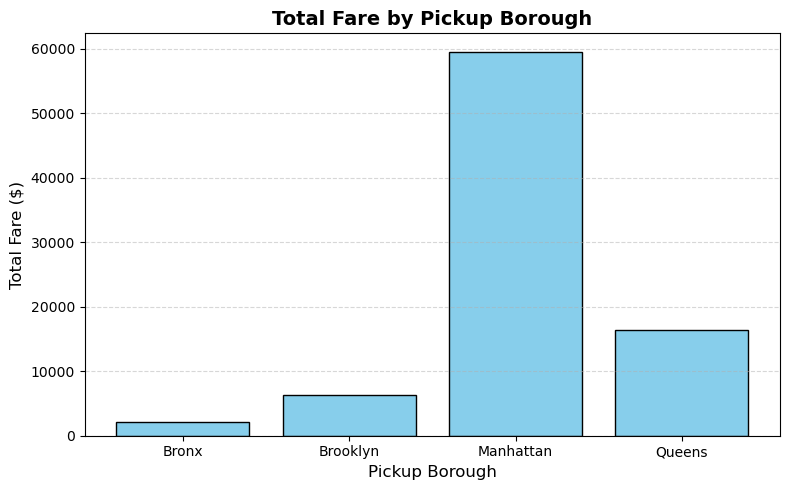

In [17]:
# 1. Group by pickup_borough and sum the fare
borough_fares = df.groupby('pickup_borough')['fare'].sum().reset_index()

# 2. Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(borough_fares['pickup_borough'], borough_fares['fare'], color='skyblue', edgecolor='black')

# 3. Formatting and labels
plt.title('Total Fare by Pickup Borough', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Total Fare ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Pie Chart

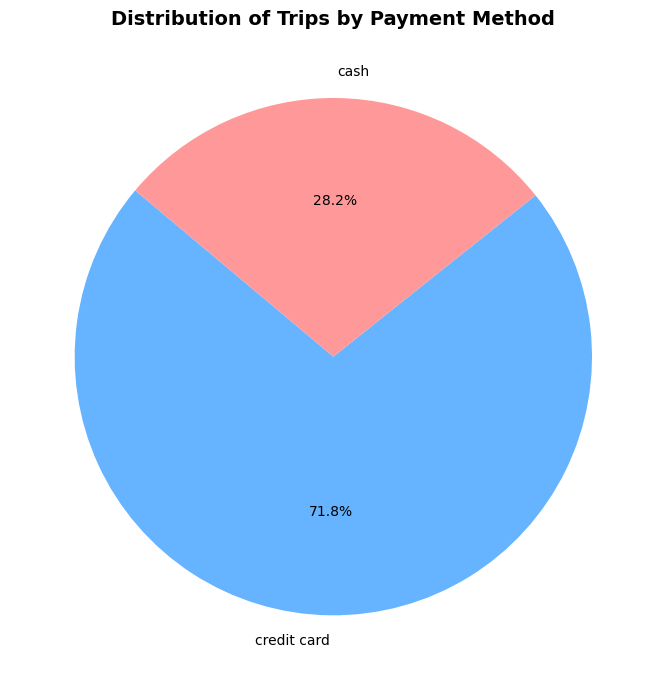

In [18]:
# 1. Count trips per payment method (handling missing values if present)
payment_counts = df['payment'].value_counts()

# 2. Plot the pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    payment_counts, 
    labels=payment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#66b3ff', '#ff9999', '#99ff99']
)

# 3. Formatting and title
plt.title('Distribution of Trips by Payment Method', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Histogram

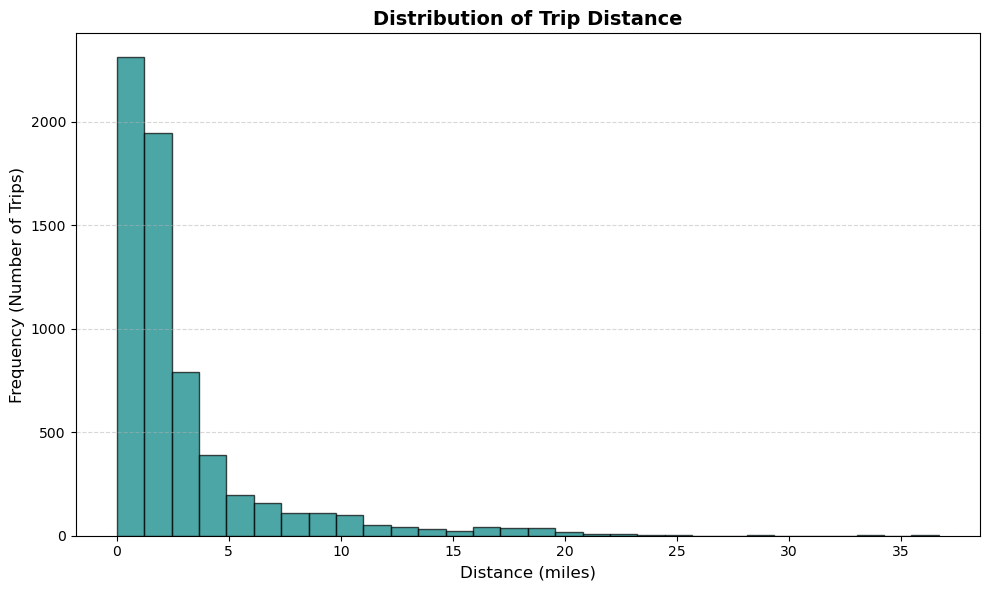

In [19]:
# 1. Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(
    df['distance'].dropna(), 
    bins=30, 
    color='teal', 
    edgecolor='black', 
    alpha=0.7
)

# 2. Formatting and labels
plt.title('Distribution of Trip Distance', fontsize=14, fontweight='bold')
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Frequency (Number of Trips)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Box Plot

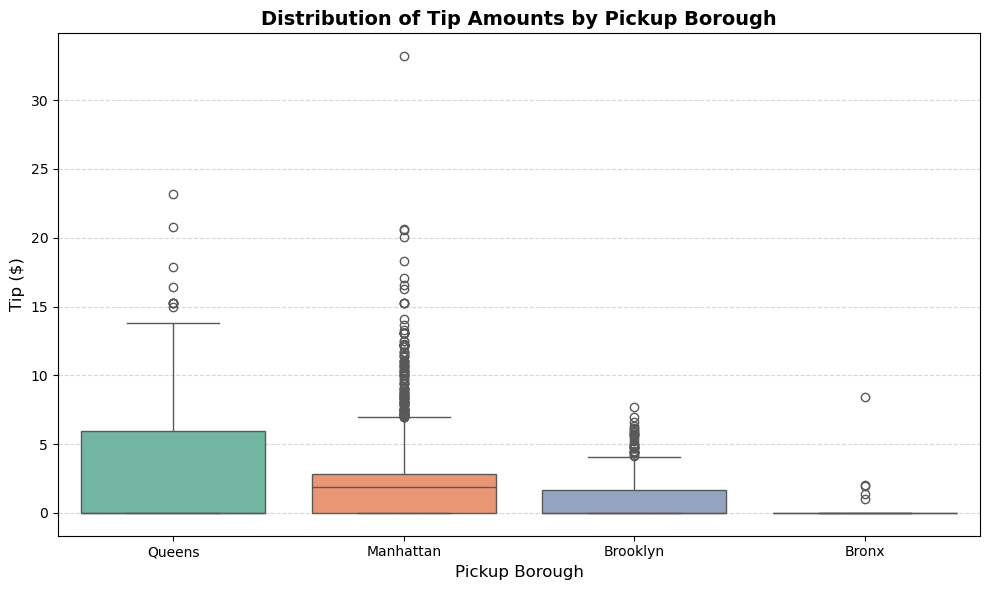

In [21]:
# 1. Create the box plot (assigning hue to pickup_borough and setting legend=False)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='pickup_borough', 
    y='tip', 
    hue='pickup_borough',
    palette='Set2',
    legend=False
)

# 2. Formatting and labels
plt.title('Distribution of Tip Amounts by Pickup Borough', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Visualizations using Seaborn:

In [ ]:
#Count Plot

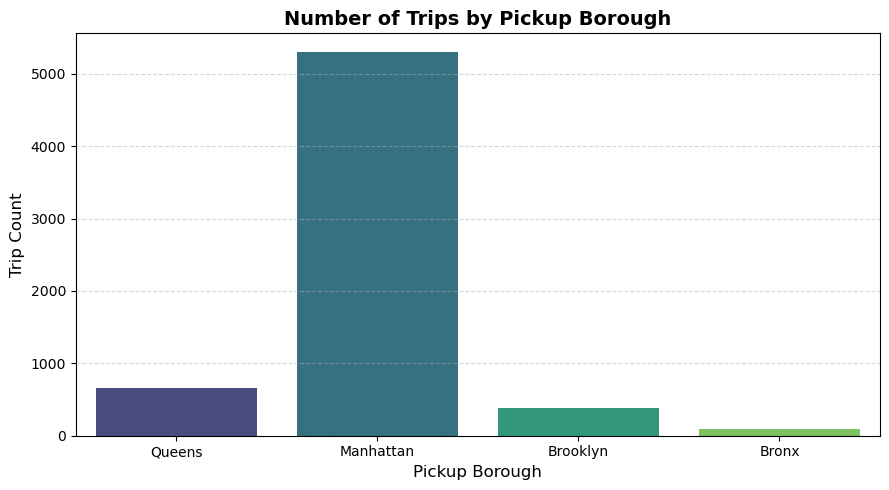

In [22]:
# 1. Create the count plot
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df, 
    x='pickup_borough', 
    hue='pickup_borough', 
    palette='viridis', 
    legend=False
)

# 2. Formatting and labels
plt.title('Number of Trips by Pickup Borough', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Trip Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Scatter Plot

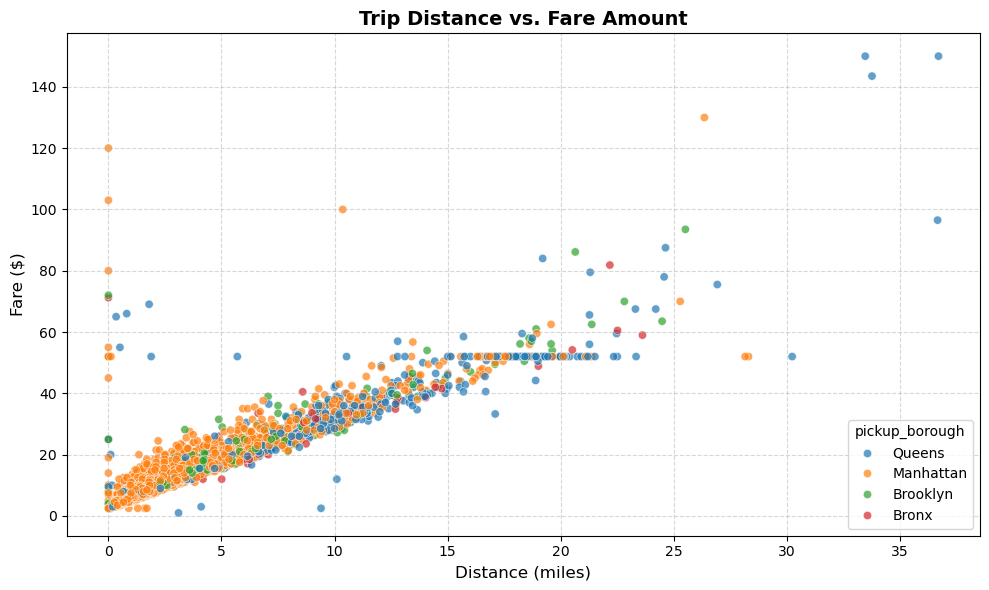

In [23]:
# 1. Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='distance', 
    y='fare', 
    hue='pickup_borough', 
    palette='tab10', 
    alpha=0.7
)

# 2. Formatting and labels
plt.title('Trip Distance vs. Fare Amount', fontsize=14, fontweight='bold')
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Heatmap

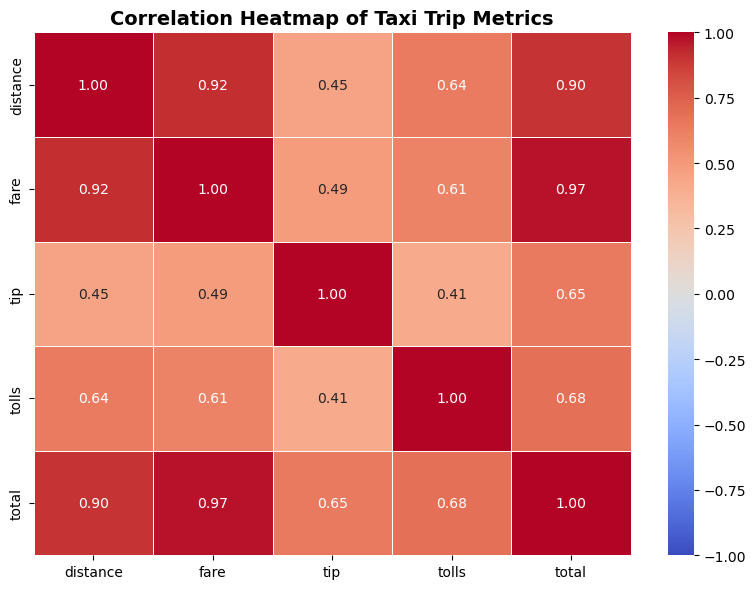

In [24]:
# 1. Select numerical columns and compute correlation matrix
num_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
corr_matrix = df[num_cols].corr()

# 2. Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

# 3. Formatting and title
plt.title('Correlation Heatmap of Taxi Trip Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#Pair Plot

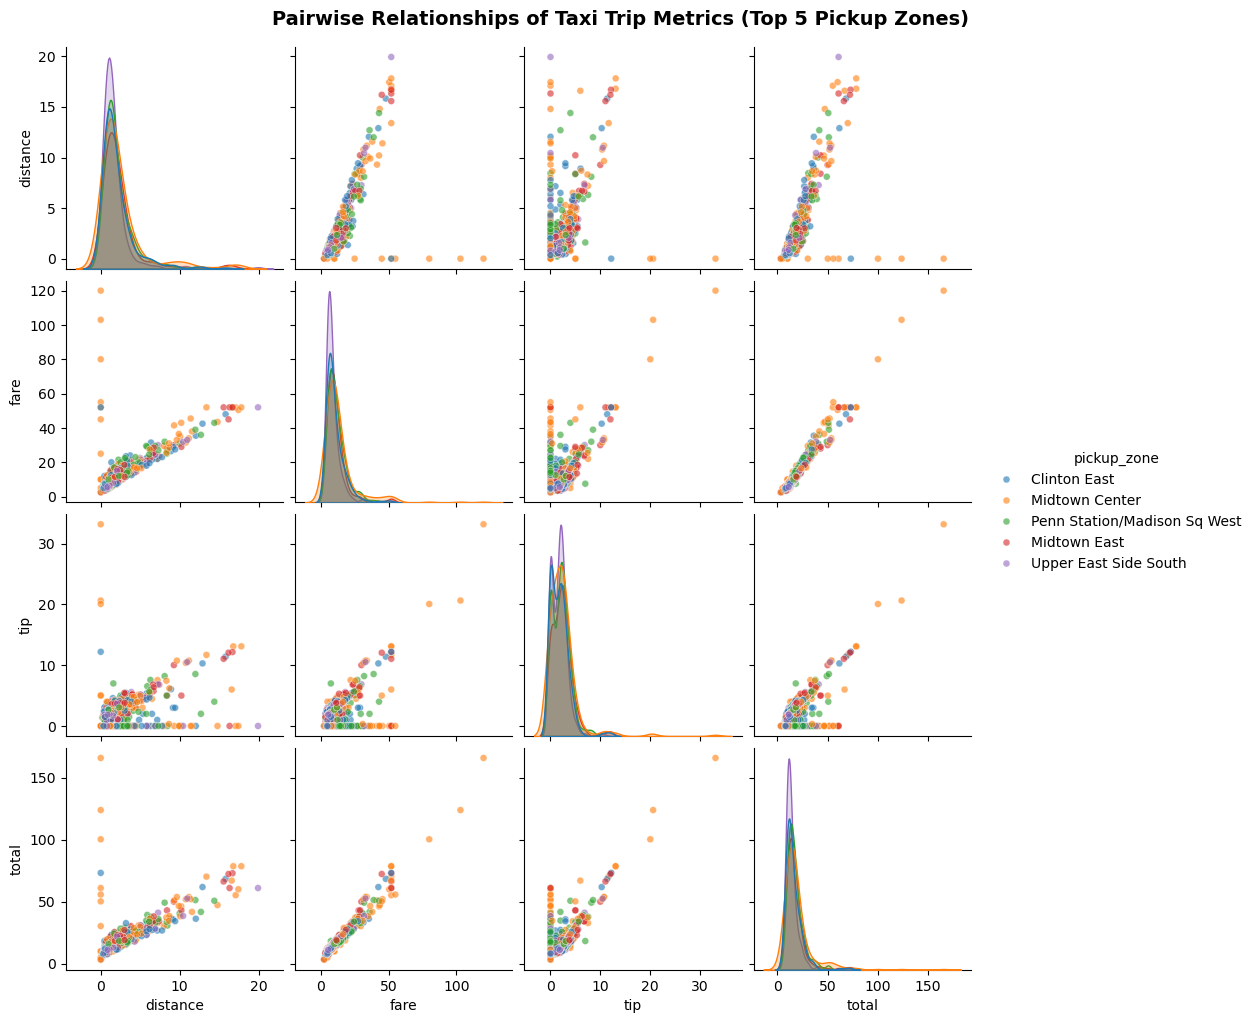

In [27]:
# 1. Select variables for pair plot
selected_cols = ['distance', 'fare', 'tip', 'total', 'pickup_zone']

# 2. Filter top 5 most frequent pickup zones to ensure clean legend display
top_zones = df['pickup_zone'].value_counts().nlargest(5).index
df_filtered = df[df['pickup_zone'].isin(top_zones)][selected_cols]

# 3. Create the pair plot
pair_grid = sns.pairplot(
    data=df_filtered, 
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone', 
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 25}
)

# 4. Add title
pair_grid.fig.suptitle(
    'Pairwise Relationships of Taxi Trip Metrics (Top 5 Pickup Zones)', 
    y=1.02, 
    fontsize=14, 
    fontweight='bold'
)

plt.show()

In [ ]:
#Violin Plot

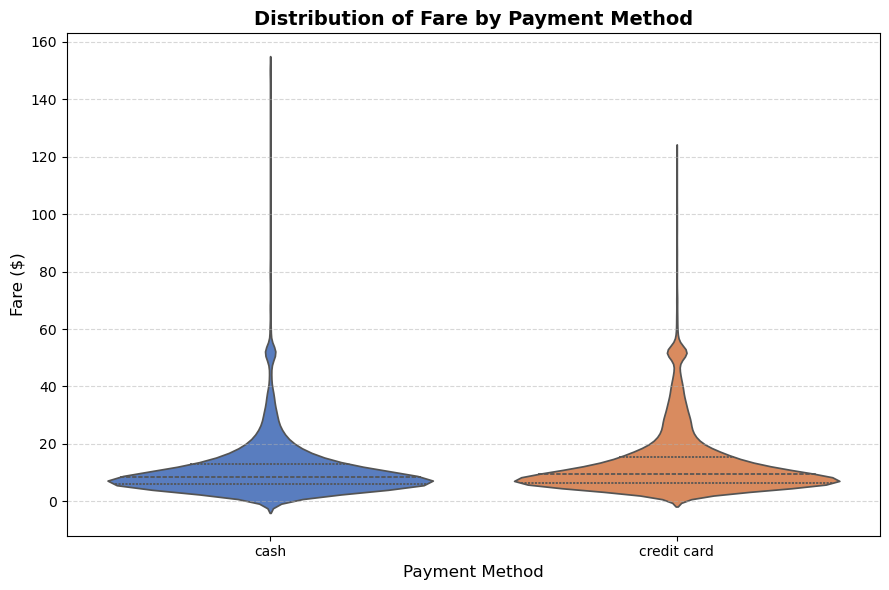

In [28]:
# 1. Create the violin plot
plt.figure(figsize=(9, 6))
sns.violinplot(
    data=df, 
    x='payment', 
    y='fare', 
    hue='payment',
    palette='muted', 
    inner='quartile',
    legend=False
)

# 2. Formatting and labels
plt.title('Distribution of Fare by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()